# 20-rh — validation package
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gamayos/finite-ring-space/blob/main/src/20-rh/validate_20rh.ipynb)

**Paper.** *Riemann Hypothesis over Finite Holographic Substrate* (Akhtman & Voether, 2026), `20-rh` of the FRC corpus.
**Package.** `finite-ring-space/src/20-rh` — seven block scripts driven by this notebook. Every cell below names the labelled
statements of the paper it checks (`Theorem`, `Proposition`, `Numerical Observation`, `Definition` — by their `\label`
as printed in the paper), lists the paper-local predicates as the block scripts register them, and gives the master-ledger
row of the corpus they witness (`00:D11` the shell theorem, `00:D12` the classical hypothesis as a screen value).
The package regenerates every numerical figure of the paper (`figures/`); the one qualitative illustration
(`carrier-domains.png`) is not a computation and is omitted.

**Kinds.** `EXACT` checks are integer-pinned finite computations (a pass is a proof on the tested instances);
`[approx]` checks compare a floating-point observation with the value the paper states, to a stated tolerance;
`[chart]` marks a continuum reading of a finite object. The discipline of the construction — *ζ never evaluated* —
binds blocks A–C: every construction there uses only the sieved von Mangoldt comb, its logarithms, and the archimedean
phase from log Γ; the Riemann heights appear as validation markers only. The control arms of block D evaluate Hurwitz
zeta functions, as the paper says they do.

**Run.** Cell by cell, or *Runtime → Run all*. Full depths take ≈ 4 min on Colab (the 8×10⁷ comb of block D is the
largest object); set `FAST = True` in the second cell for reduced depths (≈ 2 min; the same 75 predicates, the deep
tails of the depth scans shortened). The last cell writes `results.json` and fails loudly if any predicate fails.

In [ ]:
# --- environment: clone the package if this notebook is not already running inside it (Colab), install the two
# non-default dependencies. numpy, scipy, matplotlib are standard on Colab; mpmath and sympy are usually present too.
import os, sys, subprocess
if not os.path.exists("rhcommon.py"):
    if not os.path.exists("finite-ring-space"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/gamayos/finite-ring-space.git"], check=True)
    os.chdir("finite-ring-space/src/20-rh")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", "numpy>=1.24", "scipy>=1.10", "mpmath>=1.3", "sympy>=1.12", "matplotlib>=3.7"],
               check=True, env={**os.environ, "PIP_ROOT_USER_ACTION": "ignore"})
print("working directory:", os.getcwd())

working directory: /home/claude/frc-numerics-20rh


In [ ]:
FAST = False                      # True: reduced depths (≈ 2 min); False: the paper's depths (≈ 4 min)
import os
os.environ["RH_FAST"] = "1" if FAST else "0"
os.environ["RH_FIGDIR"] = "figures"
import importlib, rhcommon
importlib.reload(rhcommon)        # a fresh registry if the notebook is re-run
from IPython.display import Image, display
def show(name): display(Image(filename=f"figures/{name}.png"))
print("FAST =", FAST)

FAST = False


## Block A — the shell theorem and the exact shell arithmetic  (`a_shell.py`, EXACT, master ledger **00:D11**)
Shells p = 13, 17, 29, 37, 41 in full (every point of F_{p²}); p = 173 for A1, A4, A6. Integer arithmetic only.

| id | paper statement | predicate |
|---|---|---|
| A1 | Theorem `zeroslot` | Σ_{x∈F_p^×} x^k = 0 for every nonterminal k; = −1 on the terminal slot |
| A2 | Theorem `compl` | Φ(k) = −g^k bijects the nonterminal slots onto F_p^× ∖ {−1} |
| A3 | Lemma `K` | on F_{p²} = F_p(η): \|U_{p+1}\| = p+1, Frobenius = inversion on it, i = √−1 Frobenius-fixed with N(i) = −1 |
| A4 | Proposition `critical` | the finite critical line: Tr z = 1 ⟺ z = 2⁻¹ + bη; \|L_{1/2}\| = p; N(z) = ¼ − νb²; 2⁻¹ = 2κ+1 = −π |
| A5 | Theorem `agree` | the Klein four-group ⟨φ, ρ⟩ and its fixed loci F_p, L_{1/2}, {2⁻¹}; F_p ∩ L_{1/2} = {2⁻¹} |
| A6 | §1.3 (the Subject register) | π = 2κ, 2π ≡ −1, i = g^{−κ}, i² ≡ −1, e = g^i on the odd representative, e^{iπ} ≡ −1 |
| A7 | Theorem `hp` (i), (iii); Remark `parseval` | the constant mode carries the mean v̄ = ψ(p−1)/(p−1), the nontrivial characters carry v − v̄·1; S x^k = g^k x^k in F_p and S χ_j = ω^j χ_j on ℓ²(F_p^×); Tr S^r = (p−1)·[(p−1) \| r] |
| A8 | Theorem `hp` (iv), Definition `jacobi` | self-adjointness is free: any real multiset is the spectrum of a real-symmetric tridiagonal matrix |
| A9 | Proposition `ground` | the Ramanujan sum c_p(n) = −1 for every n ≢ 0 (mod p) |
| A10 | Definition `shells` (the shared quarter-turn core) | Q₄ ⊂ both cycles; on the pair (13, 233) the projection C_{Ω−1} → C_{p−1} does not exist (12 ∤ 232) |

In [ ]:
import a_shell; a_shell.run()


== block A: the shell theorem (00:D11) ==
  [PASS] A1   EXACT   zero-slot on F_13  --  Σx^k=0 for k=1..11; = -1 at k=12
  [PASS] A6   EXACT   Subject constants on F_13: π=2κ, i=g^-κ, e=g^i (odd rep.)  --  g=2 κ=3 π=6 i=5 e=6: 2π≡-1, i²≡-1, g^π≡-1, e^(iπ)≡-1, 2⁻¹=2κ+1=-π
  [PASS] A4   EXACT   finite critical line on F_13: Tr z = 1 ⟺ z = 2⁻¹ + bη, |L| = p, N = ¼ − νb²  --  ν=2, 2⁻¹=7
  [PASS] A2   EXACT   Φ(k) = −g^k bijects the nonterminal slots onto F_13^× \ {−1}  --  |image| = 11 = p−2
  [PASS] A3   EXACT   F_13²: |U_(p+1)| = p+1, Frobenius = inversion on it, i Frobenius-fixed with N(i) = −1
  [PASS] A5   EXACT   Klein four-group on F_13²: Fix φ = F_p, Fix σ = L_1/2, Fix ρ = {2⁻¹}, F_p ∩ L_1/2 = {2⁻¹}
  [PASS] A9   EXACT   c_13(n) = −1 for n ≠ 0
  [PASS] A7   EXACT   F_13: mean v̄ = ψ(p−1)/(p−1) on the trivial mode, v − v̄·1 on the nontrivial characters; S x^k = g^k x^k in F_p and Sχ_j = ω^j χ_j on ℓ²; Tr S^r = (p−1)[(p−1)|r]  --  v̄ = 0.852492 (= log 27720/12 at p = 13)
  [PASS] A10

## Block B — the de-framing dictionary  (`b_deframe.py`, [chart] / [approx])
Definition `deframe`: a shell of cardinality p reads ζ on the line to height T = 2πp with the Riemann–Siegel main sum of
length √p; a height is the scale coordinate of the shell that reads it. The Hardy Z function enters as the classical side of the
dictionary only.

| id | paper statement | predicate | kind |
|---|---|---|---|
| B1 | Proposition `density` | smooth zero density at T = 2πp is (1/2π) log p: 0.6226, 0.9891, 1.3556, 1.7220 at p = 50, 500, 5·10³, 5·10⁴ | [chart] |
| B2 | Numerical Observation `residue` | the finite-horizon residue \|Z_horizon − Z\| ∝ p^{−1/4} (log-log slope ≈ −1/4) | [approx] |
| B3 | Proposition `critical` (de-framing limit) | 2⁻¹/p = (2κ+1)/p → ½ from above | [chart] |
| B4 | Definition `deframe` | the horizon-length main sum has one sign change per zero on [10, 55], each within 0.5 of γ_n | [approx] |


== block B: the de-framing dictionary (Def. deframe) ==
  [PASS] B1   [chart] smooth zero density at T = 2πp is (1/2π) log p  --  p=50: 0.6226  p=500: 0.9891  p=5000: 1.3556  p=50000: 1.7220
  [PASS] B3   [chart] de-framing limit (2κ+1)/p → ½ from above  --  13: 0.53846  53: 0.50943  101: 0.50495  409: 0.50122  1009: 0.50050  10009: 0.50005


    (horizon sums on [10,55]: 0.5 s)
  [PASS] B4   [approx] the bare horizon-length main sum has one sign change per zero on [10,55], each within 0.5 of γ_n  --  11 sign changes for 11 zeros; max deviation 0.40 (1–2 terms only at these heights)


    (residue scan: 1.0 s)
  [PASS] B2   [approx] reconstruction residue ∝ p^{-1/4}: fitted log-log slope in [−0.40, −0.10]  --  slope = -0.242


    wrote figures/fig_deframing.pdf


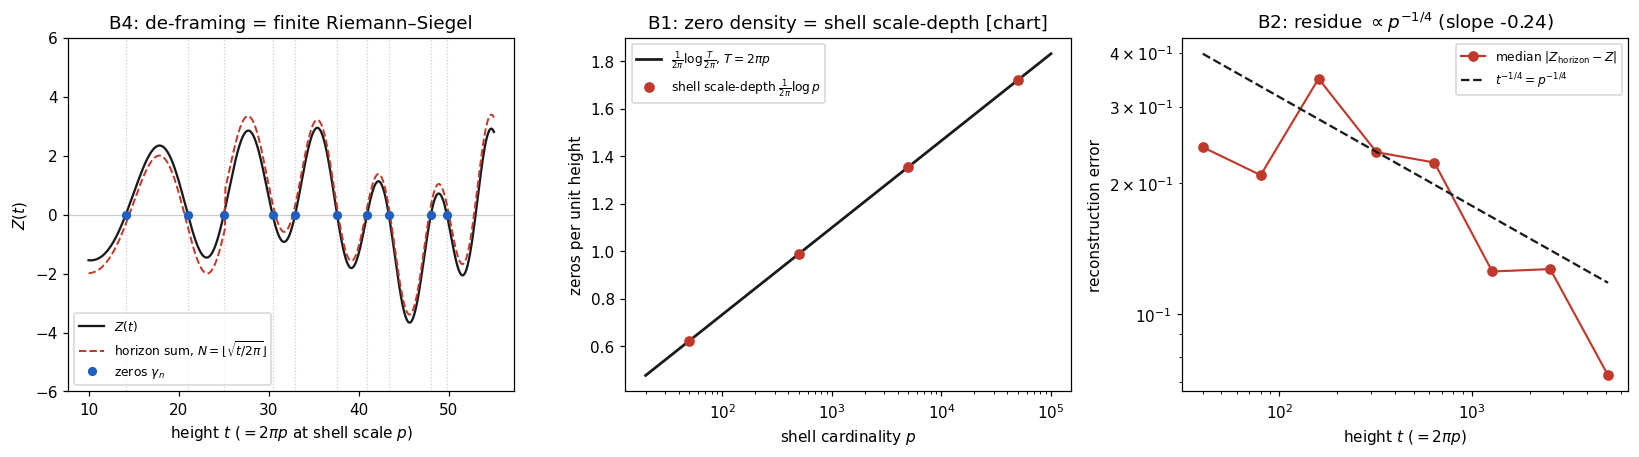

In [ ]:
import b_deframe; b_deframe.run(); show('fig_deframing')

## Block C — the spectrum from the prime side, ζ never evaluated  (`c_primeside.py`, [approx])
Inputs: the sieved comb {Λ(n)}, its logarithms, the raised-cosine taper, and θ(T) from log Γ. Ñ_N(T) = θ(T)/π + 1 + S_comb(T).

| id | paper statement | predicate |
|---|---|---|
| C1 | Numerical Observation `primespec` | the scale-spectrum \|Σ_N(γ)\| of the N = 10⁶ comb peaks at the first six heights (paper: 14.14, 21.02, 25.02, 30.40, 32.96, 37.57) within 0.03 |
| C2 | Numerical Observation `trace` | the secular condition Ñ_N(T) = n − ½ recovers the first ten heights: mean 4.4×10⁻⁵, max 1.5×10⁻⁴ at N = 10⁶; 3.6×10⁻⁴ at 10³, 6×10⁻⁵ at 10⁵ |
| C3 | Numerical Observation `matrix` | the colleague matrix of the Chebyshev fit of cos(π Ñ_N) on [10, 52]: mean error 5.9×10⁻⁵ at dimension 520, ≈ 4.5×10⁻⁵ by 620 |
| C4 | Definition `jacobi`, Numerical Observation `jacobi` | the comb-built Jacobi matrix: real-symmetric tridiagonal, eigenvalues = secular roots to 10⁻¹², the stated a, b coefficients |
| C5 | Proposition `gauge` | the additive injection −i d/du + V_comb is gauge-trivial: spacing standard deviation 0.08 (absolute; 0.11 of the mean) against 0.39 of the mean for the heights (two conventions in the paper's sentence — README) |


== block C: the prime-side realisation, ζ never evaluated ==
    (comb to 1000000: 0.0 s)


    (scale-spectrum: 17.2 s)
  [PASS] C1   [approx] scale-spectrum peaks at the stated 14.14 … 37.57 (within 0.015) and at γ_1..γ_6 (within 0.05, the taper's width); each peak ≥ 4× the baseline  --  peaks 14.15, 21.02, 25.03, 30.40, 32.97, 37.58; max |peak − γ| 0.030; min peak/baseline 6.2
  [PASS] C2   [approx] secular condition: ten heights to mean 4.4e-5, max 1.5e-4 at N = 10⁶; sharpening with depth  --  N=1e+03: mean 3.62e-04 max 7.58e-04; N=1e+05: mean 6.00e-05 max 1.67e-04; N=1e+06: mean 4.40e-05 max 1.46e-04
  [PASS] C4   [approx] Jacobi matrix: real-symmetric tridiagonal; eig = secular roots to 1e-12; a, b as stated; heights to 4.4e-5  --  max|eig−roots| = 2.1e-14; a[0..2] = 34.314, 31.021, 31.178; b[0] = 11.178


    (colleague matrices: 3.4 s)
  [PASS] C3   [approx] colleague matrix on [10,52]: mean error 5.9e-5 at dim 520, ≈4.5e-5 by 620  --  dim 180: 1.41e-02; dim 260: 3.62e-03; dim 340: 8.10e-04; dim 420: 2.83e-04; dim 520: 5.90e-05; dim 620: 4.49e-05


    (additive operator: 3.8 s)
  [PASS] C5   [approx] additive −i d/du + V_comb has a uniform spectrum: spacing std 0.08 (0.11 of its mean) against 0.39 of the mean for the heights  --  additive: std 0.078 on mean spacing 0.715 (ratio 0.109); heights: std 1.54 on mean 3.96 (ratio 0.389) — the paper's 0.08 is the absolute std, its 0.39 the ratio


    wrote figures/fig_prime_spectrum.pdf


    wrote figures/fig_operator_spectrum.pdf


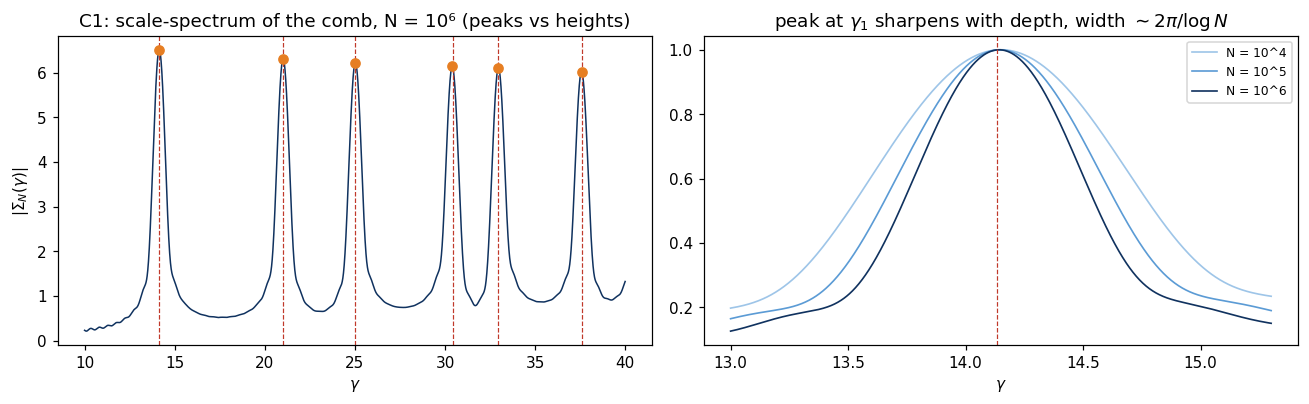

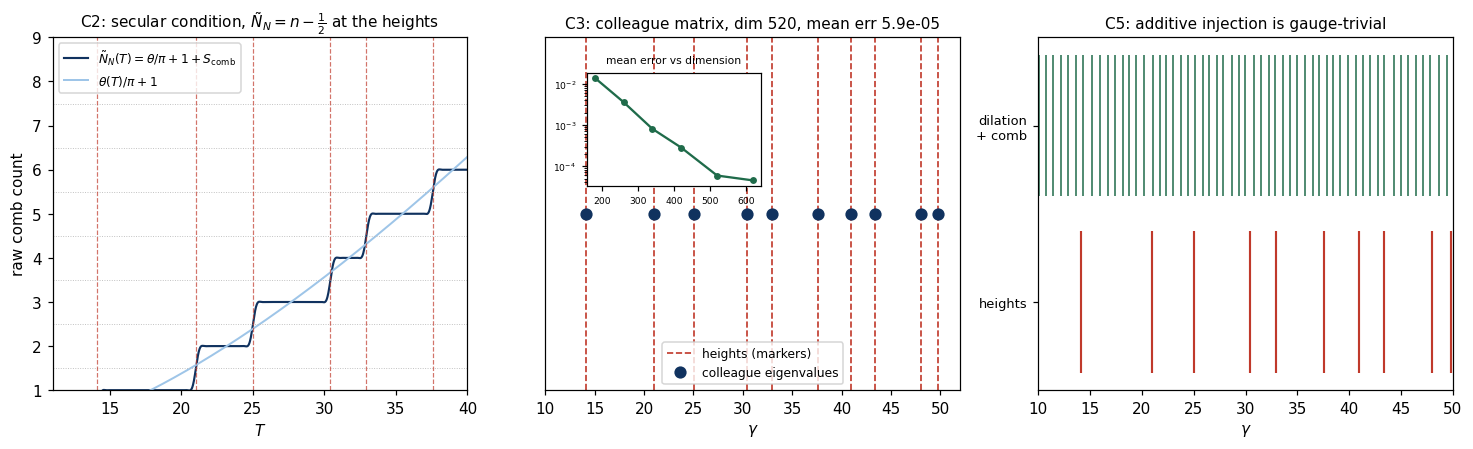

In [ ]:
import c_primeside; c_primeside.run(); show('fig_prime_spectrum'); show('fig_operator_spectrum')

### Block C, continued — random-matrix statistics of the target spectrum  (`c_gue.py`)
Definition `specmap` reads the heights as the target spectrum ρ ↦ −i(ρ − ½); the heights here are computed independently (mpmath `zetazero`).

| id | paper statement | predicate | kind |
|---|---|---|---|
| C6 | Numerical Observation `gue` | unfolded spacings of the first 240 zeros: P(s < ½) = 0.05 (GUE ≈ 0.12, Poisson ≈ 0.39), variance 0.13 (GUE ≈ 0.18, Poisson 1) | [approx] |
| C6b | Figure `hp` (right) | the count N(T) lies on the Berry–Keating (T/2π)(log(T/2π) − 1) + 7/8: density (1/2π) log p at T = 2πp | [chart] |


== block C (continued): GUE level repulsion of the target spectrum (Obs. gue) ==
    (first 240 zeros (mpmath zetazero): 0.0 s)
  [PASS] C6   [approx] unfolded spacings of the first 240 zeros: P(s<½) ≈ 0.05, variance ≈ 0.13 (repulsion; far from Poisson)  --  P(s<½) = 0.050 (GUE 0.112, Poisson 0.393); var = 0.133 (GUE 0.178, Poisson 1)
  [PASS] C6b  [chart] eigenvalue count N(T) within 1.5 of the Berry–Keating smooth count on [10, γ_240]  --  max |N − N̄| = 0.91; mean = 0.30


    wrote figures/fig_hilbert_polya.pdf


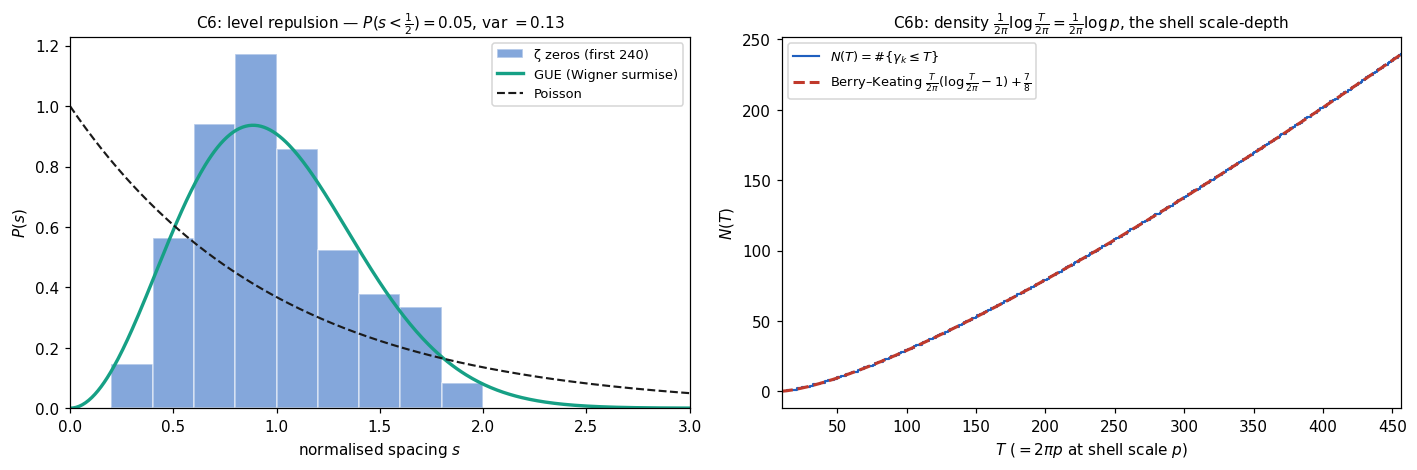

In [ ]:
import c_gue; c_gue.run(); show('fig_hilbert_polya')

### Block C, continued — the χ-twisted comb  (`c_chi.py`, [approx])
Proposition `chi` (real character case), Numerical Observation `chi`: χ = χ_{−4}, θ_χ(t) = Im log Γ(¾ + it/2) + (t/2) log(4/π),
N_χ = θ_χ/π + S^χ_comb with no pole term; validation arm L(s, χ) = 4^{−s}[ζ(s, ¼) − ζ(s, ¾)] via Hurwitz zeta.

| id | predicate |
|---|---|
| C7a | N_χ at the first six zeros of L(s, χ_{−4}) reads 0.4997, 1.4998, 2.4999, 3.4999, 4.4999, 5.4998; the completed L is real on the line |
| C7b | the twisted secular condition with the N = 10⁶ comb, L never evaluated, recovers 6.0209, 10.2438, 12.9881, 16.3426, 18.2920, 21.4506 to mean error 8.6×10⁻⁵ |

In [ ]:
import c_chi; c_chi.run()


== block C (continued): the χ-twisted comb, χ = χ_{−4} (Prop. chi, Obs. chi) ==


    (Hurwitz-zeta validation arm: 5.4 s)
    (twisted comb to 1000000: 0.0 s)
  [PASS] C7a  [approx] N_χ at the first six zeros of L(s, χ_{−4}) reads 0.4997 … 5.4998 (completed L real on the line)  --  zeros 6.0209, 10.2438, 12.9881, 16.3426, 18.2920, 21.4506; N_χ 0.4997, 1.4998, 2.4999, 3.4999, 4.4999, 5.4998; max|Im Λ| = 1.1e-21
  [PASS] C7b  [approx] twisted secular condition, N = 10⁶ comb, L never evaluated: six heights to mean error 8.6e-5  --  roots 6.0211, 10.2439, 12.9882, 16.3427, 18.2921, 21.4507; mean error 8.60e-05, max 1.55e-04


## Block D — the classification and the Euler-product discriminator  (`d_classification.py`, [approx], master ledger **00:D12**)
Theorem `turing`: C ≤ N_crit ≤ N; RH below T is N = N_crit; C = N is Turing's practical certificate, read on the shell from the two
sides of the explicit formula (both readings uncertified). Corollary `conditional`: the classical hypothesis is the screen value
N − N_crit = 0. Numerical Observation `dh`: the value is discriminating. The control arms evaluate Hurwitz zeta functions.

| id | paper statement | predicate |
|---|---|---|
| D1 | Theorem `turing`, Corollary `conditional` | Ñ_N rounds to N = 1, 3, 10 at T = 15, 30, 50.3; sign changes of the horizon main sum give C = 1, 3, 10 = N |
| D2a | Numerical Observation `dh` | the completed Davenport–Heilbronn Λ_f(½ + it) is real to 10⁻²⁰ |
| D2b | Numerical Observation `dh` | argument principle by band on [0, 87]: f: 45 strip zeros vs 43 on-line sign changes, the deficit 2 opening only in the band of the off-line pair 0.8085171825 + 85.6993484854 i (validated \|f\| < 10⁻⁶); \|Z_f\| dips to 0.357 at 85.71; control L(s, χ): 45 = 45, deficit 0 in every band |
| D2c | Numerical Observation `dh` | the secular condition on the Λ_f comb lands two "on-line" roots on the phantom height: 85.63/85.76 (10⁵), 85.65/85.75 (4×10⁵) |
| D2d | Numerical Observation `dh` | the raw DH count at 85.9 drifts 45.14 → 45.73 over depths 5×10⁴ … 8×10⁵; 42.66 … 42.73 at 85.3; stable at 60.3 (28.005 ± 0.002) and 84.0 (43.00 ± 0.01) |
| D2e | Numerical Observation `dh` | the ζ comb at the pole: t = 1 reads +0.09, −0.26, +0.36, −0.08, −0.81, −1.42, −1.46 at depths 10⁴ … 8×10⁷; t = 5, 10 within ±0.02, ±0.003; t = 15 within 2×10⁻³ of 1; t = 30 from 3.04 to 2.998; t = 50.3 within 10⁻² of 10 |


== block D: the classification and the Euler-product discriminator (Thm. turing, Cor. conditional, Obs. dh) ==
  [PASS] D1   [approx] Ñ_N rounds to N = 1, 3, 10 at T = 15, 30, 50.3; sign changes of the main sum Z_M give C = 1, 3, 10 = N  --  raw 1.0003, 2.9944, 10.0037; C_M = [1, 3, 10]


  [PASS] D2a  [approx] the completed Λ_f(½ + it) is real on the line to 10⁻²⁰  --  max |Im Λ_f| = 5.8e-23 over 25 heights


    (on-line grid (Hurwitz zeta): 34.0 s)


    (argument principle on 29 bands (Hurwitz zeta): 63.8 s)
  [PASS] D2b  [approx] argument principle on [0,87]: f: 45 strip zeros vs 43 on-line, deficit 2 only in the band of the off-line pair; L(s,χ): 45 = 45, deficit 0 everywhere  --  f: N = 45, C = 43, deficit by band [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]; L(s,χ): N = 45, C = 45; |f(s_off)| = 6.1e-11; |Z_f| dips to 0.357 at t = 85.70


    (Λ_f comb to 8e5 (divisor recursion): 1.2 s)


...

  [PASS] D2d  [approx] raw DH comb count drifts monotonically at t = 85.9 (45.14 → 45.73) and reads 42.66 … 42.73 at 85.3 (interior depths dip to 42.64); stable at 60.3 (28.005 ± 0.002) and 84.0 (43.00 ± 0.01)  --  t=85.9: 45.135, 45.269, 45.413, 45.567, 45.729; t=85.3: 42.659, 42.640, 42.645, 42.676, 42.734; t=60.3: 28.005, 28.006, 28.006, 28.005, 28.004; t=84.0: 42.991, 42.995, 43.005, 43.008, 43.001


    (ζ comb support to 8e+07: 1.5 s)


  [PASS] D2e  [approx] ζ comb at the pole: t = 1 reads +0.09, −0.26, +0.36, −0.08, −0.81, −1.42, −1.46 with depth (exact 0); t = 5, 10 within ±0.02, ±0.003; t = 15 within 2e-3 of 1; t = 30 3.04 → 2.998; t = 50.3 within 1e-2 of 10  --  t=1: +0.09, -0.26, +0.36, -0.08, -0.81, -1.42, -1.46; t=5: max|·| 0.018; t=10: 0.0024; t=15: max dev 1.7e-03; t=30: 3.042 → 2.998; t=50.3: max dev 8.0e-03


    (window grid [84,87]: 6.4 s)


    wrote figures/fig_dh.pdf


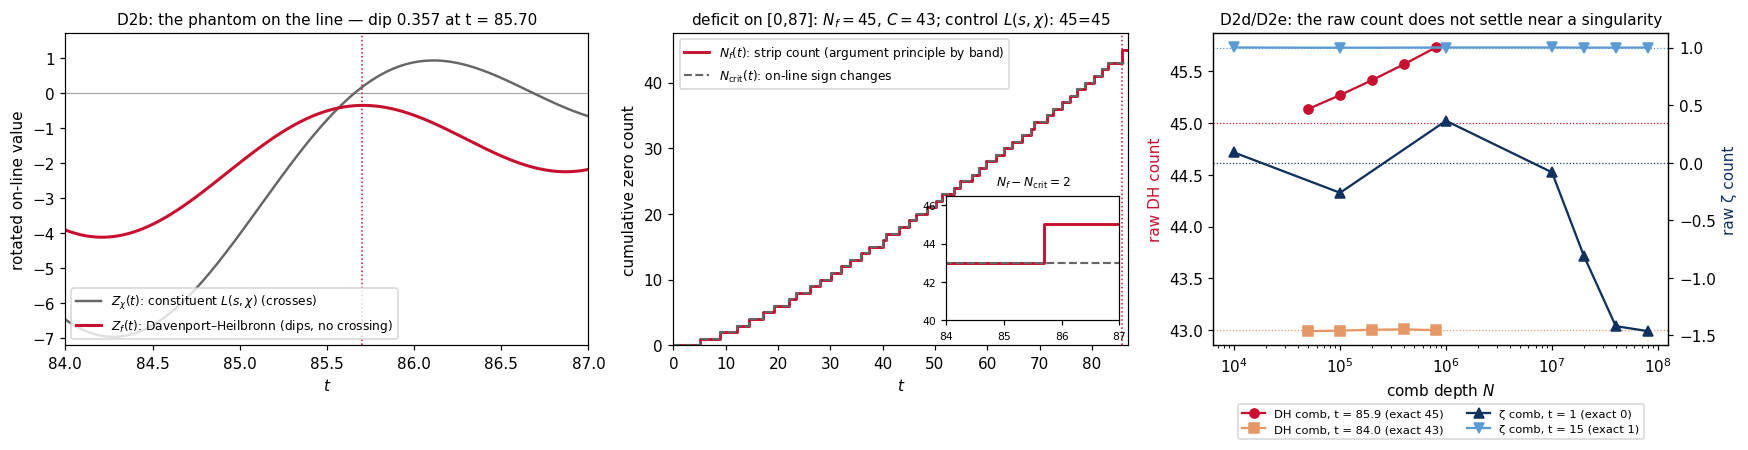

In [ ]:
import d_classification; d_classification.run(); show('fig_dh')

## Block E — resonance, antipode, horizon-scale resolution, square-root cancellation  (`e_resonance.py`)
The units-chart side: Ramanujan sums as the standing waves of the additive meridian, the Möbius-weighted resonance and its limit.

| id | paper statement | predicate | kind |
|---|---|---|---|
| E1a | Theorem `resonance` (b) | Λ = μ ∗ log on the divisor lattice: symbolic for n ≤ 300 (sympy), floating point for n ≤ 5000 | EXACT |
| E1b | Theorem `resonance` (a), (c) | Hardy: R_L(n) → (φ(n)/n) Λ(n) (Cesàro mean to L = 4000); the intertwiner (n/φ(n)) R → Λ = log ℓ | [approx] |
| E1c | Definition `resonance`, Figure `emergence` | Ψ_L(N) = Σ_{n≤N} (n/φ(n)) R_L(n) → ψ(N): the maximal deviation on N ≤ 30 falls over L = 15, 60, 240 | [approx] |
| E2a | Numerical Observation `antipode` | per-mode energy μ²(q)/φ(q) = 1, ½, ¼, ⅙ at q = 2, 3, 5, 7; unique global maximum at the antipode q = 2 | EXACT |
| E2b | Numerical Observation `antipode` | the additive-transform band energy of the prime indicator (p = 10007) peaks at the antipode and follows 1/φ(q) — reported against the paper's 1220 > 640 > 323 > 214, not pinned (normalisation unstated; README) | [approx] |
| E3 | Numerical Observation `horizon` | the resolving threshold L*(H) exists for H = 6 … 50 and tracks the horizon: L* < 6H ≪ H² | [approx] |
| E4 | Proposition `flat`, Numerical Observation `flat` | the maximal chart-mode correlation with the primes sits at the 1/√p floor: 0.08 vs 0.03 at p = 1009, 0.0087 vs 0.0032 over the 5×10⁴ modes of p ≈ 10⁵; the resonance correlates 0.90 | [approx] |


== block E: resonance, antipode, horizon, square-root cancellation ==
    (resonance table: 0.0 s)


  [PASS] E1a  EXACT   Λ = μ ∗ log: −Σ_{d|n} μ(d) log d = Λ(n), symbolic for n ≤ 300, floating point for n ≤ 5000  --  symbolic ok; max float deviation 3.6e-15
    (Cesàro resonance to L = 4000: 0.1 s)
  [PASS] E1b  [approx] Hardy: R_L(n) → (φ(n)/n) Λ(n) on prime powers, → 0 off them; intertwiner (n/φ(n)) R → Λ = log ℓ  --  R(2) = 0.3469 vs ½ log 2 = 0.3466; R(9) = 0.7337 vs ⅔ log 3 = 0.7324; (13/12) R(13) = 2.5720 vs log 13 = 2.5649; max |R| off prime powers 0.002
  [PASS] E1c  [approx] Ψ_L(N) → ψ(N) on N ≤ 30: maximal deviation falls monotonically over L = 15, 60, 240  --  max |Ψ_L − ψ| = 3.564, 2.076, 0.326
  [PASS] E2a  EXACT   per-mode energy μ²(q)/φ(q) = 1, ½, ¼, ⅙ at q = 2, 3, 5, 7; unique global maximum at the antipode q = 2 (q ≤ 2000)  --  energies q=2: 1, q=3: 1/2, q=5: 1/4, q=7: 1/6, q=11: 1/10
  [PASS] E2b  [approx] additive-transform band energy of the prime indicator (p = 10007) peaks at the antipode and follows 1/φ(q): q = 2 > 3 > 5 > 7  --  band energy (Parseval-normalis

    wrote figures/fig_obstruction.pdf


    wrote figures/fig_emergence_frc.pdf


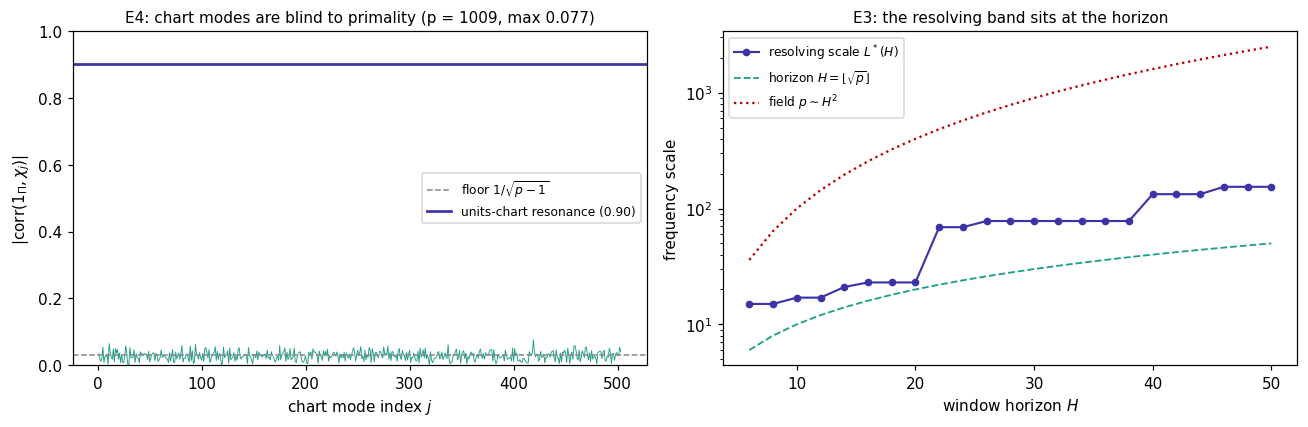

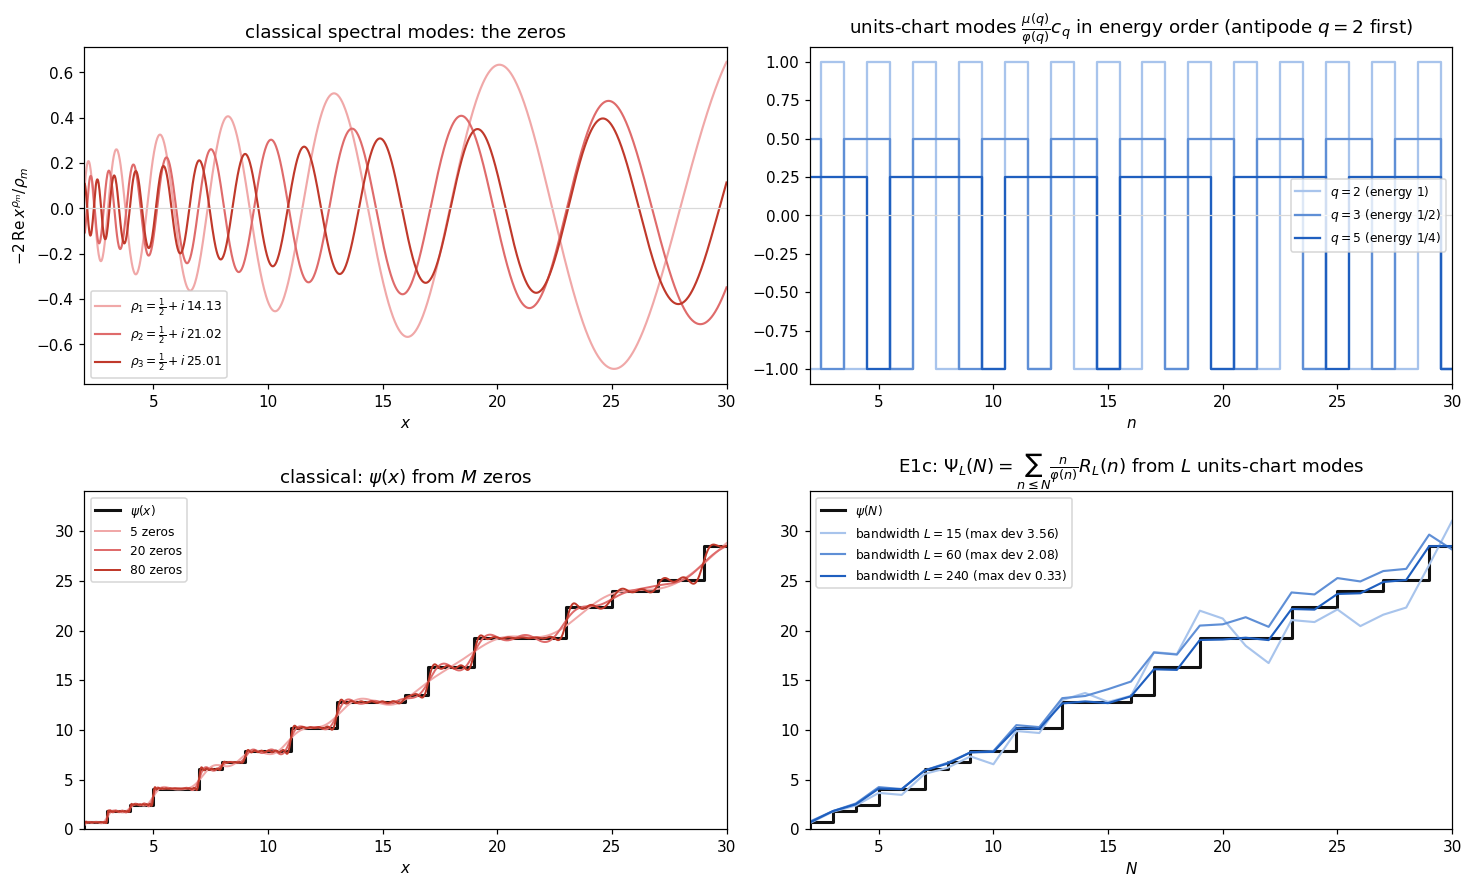

In [ ]:
import e_resonance; e_resonance.run(); show('fig_obstruction'); show('fig_emergence_frc')

## Summary
Writes `results.json` (one record per predicate: id, label, kind, PASS/FAIL, detail) and raises if any predicate failed.

In [ ]:
ok = rhcommon.summary(write=True)
kinds = {}
for r in rhcommon.RESULTS: kinds[r["kind"]] = kinds.get(r["kind"], 0) + 1
print("by kind:", ", ".join(f"{k} {v}" for k, v in sorted(kinds.items())))
failed = [r["id"] for r in rhcommon.RESULTS if not r["ok"]]
assert ok, f"FAILED predicates: {failed}"
print("all predicates pass; figures in figures/, records in results.json")


SUMMARY: 75/75 checks passed
by kind: EXACT 51, [approx] 21, [chart] 3
all predicates pass; figures in figures/, records in results.json
